# Notebook 04: Identity Forensics — Trajectory, Attribution & Fingerprints
**Ship of Theseus — Computational Forensics Project**

This notebook addresses:
- **RQ2**: Identity Trajectory (t-SNE/PCA) + Authorship Attribution ("Point of No Return")
- **RQ3**: Paraphraser Fingerprint Classification

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve().parents[0]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.config import DATA_PROCESSED, DATASETS, STAGES, FAMILIES

FIGURES = ROOT / "figures" / "identity_forensics"
EXP_DATA = ROOT / "experiments" / "identity_forensics"
FIGURES.mkdir(parents=True, exist_ok=True)
EXP_DATA.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

Project root: /Users/joshcho/Documents/after 15/NEU/NLP/ShipOfTheseus-NLP-Project


## Load Chain Data
Use **all 7 datasets** with 500 samples each for robust analysis.

In [2]:
SAMPLE_N = 500
SEED = 42

# Use ALL 7 datasets for more robust results
chains = {}
for name in DATASETS.keys():
    path = DATA_PROCESSED / f"{name}_chains.csv"
    df = pd.read_csv(path)
    chains[name] = df.sample(min(SAMPLE_N, len(df)), random_state=SEED)
    print(f"Loaded '{name}': {chains[name].shape}")

# Combine all
combined_chains = pd.concat(chains.values(), ignore_index=True)
print(f"\nCombined: {combined_chains.shape}")
print(f"Sources: {combined_chains['source'].value_counts().to_dict()}")
print(f"Families: {combined_chains['family'].value_counts().to_dict()}")

# Show Human vs AI ratio
n_human = (combined_chains['source'] == 'Human').sum()
n_ai = (combined_chains['source'] != 'Human').sum()
print(f"\nHuman: {n_human} ({n_human/len(combined_chains)*100:.1f}%)")
print(f"AI:    {n_ai} ({n_ai/len(combined_chains)*100:.1f}%)")

Loaded 'sci_gen': (500, 8)


Loaded 'wp': (500, 8)


Loaded 'xsum': (500, 8)


Loaded 'eli5': (500, 8)


Loaded 'cmv': (500, 8)


Loaded 'tldr': (500, 8)


Loaded 'yelp': (500, 8)

Combined: (3500, 8)
Sources: {'OpenAI': 571, 'LLAMA': 547, 'Human': 539, 'Tsinghua': 521, 'BigScience': 520, 'PaLM': 402, 'Eleuther-AI': 400}
Families: {'dipper': 1540, 'pegasus': 992, 'palm': 497, 'chatgpt': 471}

Human: 539 (15.4%)
AI:    2961 (84.6%)


---
## Section 1: Identity Trajectory (t-SNE / PCA)

Vectorize texts at each stage using TF-IDF, then project to 2D with PCA → t-SNE.
Color by stage to show the "drift" from Human region toward Machine region.

**Important**: We also compute silhouette scores as quantitative support
(to avoid the pitfall of over-interpreting t-SNE without quantitative evidence).

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Collect all texts with stage labels
tsne_texts = []
tsne_labels = []
tsne_families = []

for _, row in combined_chains.iterrows():
    for stage in STAGES:
        text = row[stage]
        if pd.notna(text) and len(str(text).strip()) > 0:
            tsne_texts.append(str(text)[:3000])  # truncate for speed
            tsne_labels.append(stage)
            tsne_families.append(row['family'])

print(f"Total texts for t-SNE: {len(tsne_texts)}")
print(f"Stage distribution: {pd.Series(tsne_labels).value_counts().to_dict()}")

Total texts for t-SNE: 13964
Stage distribution: {'T0': 3500, 'T1': 3500, 'T2': 3496, 'T3': 3468}


In [4]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(tsne_texts)
print(f"TF-IDF matrix: {X_tfidf.shape}")

# PCA to 50 dims first (speeds up t-SNE and reduces noise)
pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_tfidf.toarray())
print(f"PCA explained variance (50 dims): {pca.explained_variance_ratio_.sum():.3f}")

# t-SNE to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca)
print(f"t-SNE output: {X_tsne.shape}")

TF-IDF matrix: (13964, 3000)


PCA explained variance (50 dims): 0.148


/opt/homebrew/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE output: (13964, 2)


In [5]:
# Quantitative support: silhouette score by stage
stage_labels_numeric = [STAGES.index(s) for s in tsne_labels]
sil_tsne = silhouette_score(X_tsne, stage_labels_numeric)
sil_pca = silhouette_score(X_pca, stage_labels_numeric)
print(f"Silhouette Score (t-SNE space, by stage): {sil_tsne:.4f}")
print(f"Silhouette Score (PCA space, by stage):   {sil_pca:.4f}")
print("\n(Higher = better stage separation. >0.1 = meaningful, <0 = overlapping)")

Silhouette Score (t-SNE space, by stage): -0.0141
Silhouette Score (PCA space, by stage):   -0.0036

(Higher = better stage separation. >0.1 = meaningful, <0 = overlapping)


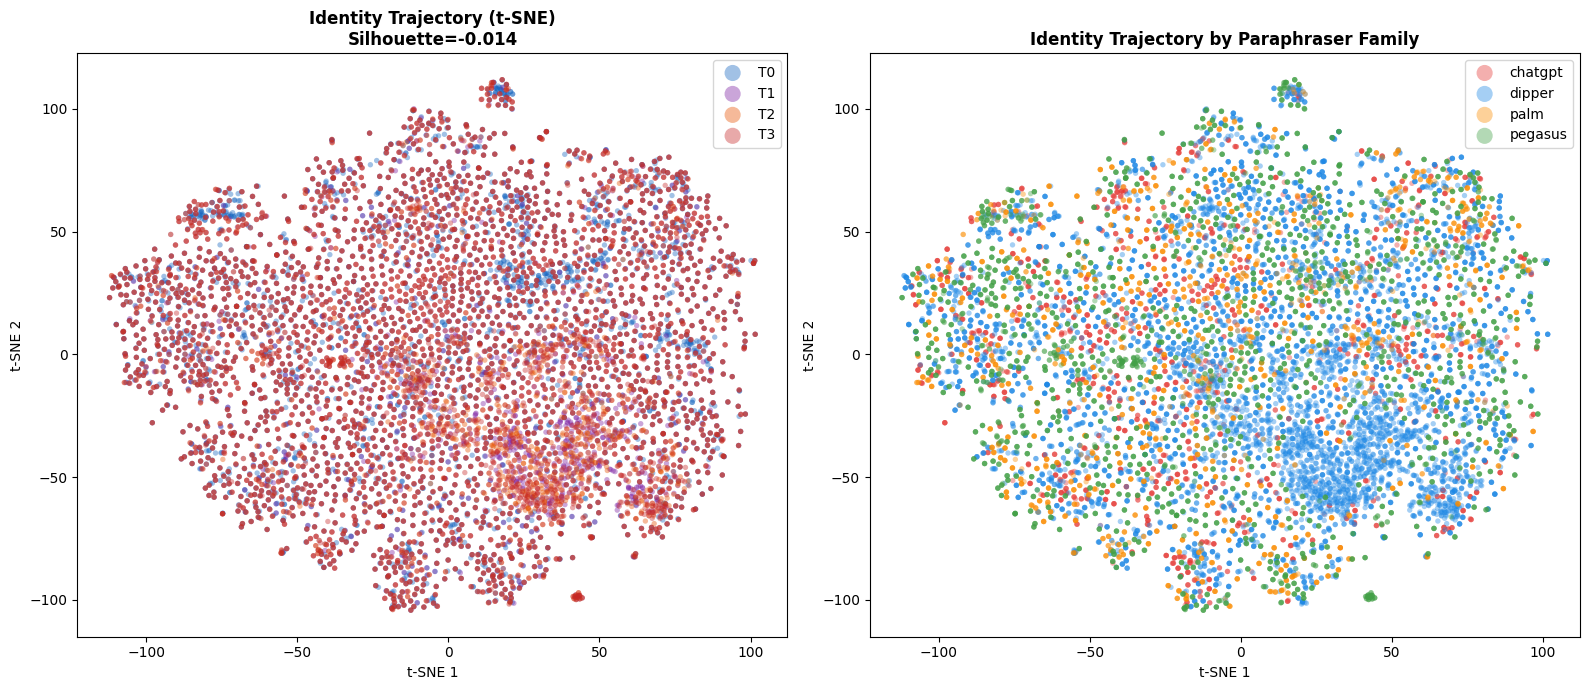

Saved: fig1_identity_trajectory_tsne.png


In [6]:
# Plot Identity Trajectory
stage_colors = {'T0': '#1565C0', 'T1': '#7B1FA2', 'T2': '#E65100', 'T3': '#C62828'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Color by stage
ax = axes[0]
for stage in STAGES:
    mask = [l == stage for l in tsne_labels]
    pts = X_tsne[mask]
    ax.scatter(pts[:, 0], pts[:, 1], c=stage_colors[stage], label=stage,
               alpha=0.4, s=15, edgecolors='none')
ax.set_title(f"Identity Trajectory (t-SNE)\nSilhouette={sil_tsne:.3f}",
             fontweight='bold')
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=3)

# Right: Color by paraphraser family
ax = axes[1]
family_colors = {'chatgpt': '#E53935', 'dipper': '#1E88E5',
                 'pegasus': '#43A047', 'palm': '#FB8C00', 'none': '#757575'}
for fam in sorted(set(tsne_families)):
    mask = [f == fam for f in tsne_families]
    pts = X_tsne[mask]
    ax.scatter(pts[:, 0], pts[:, 1], c=family_colors.get(fam, '#999'),
               label=fam, alpha=0.4, s=15, edgecolors='none')
ax.set_title("Identity Trajectory by Paraphraser Family", fontweight='bold')
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=3)

plt.tight_layout()
plt.savefig(FIGURES / 'fig1_identity_trajectory_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_identity_trajectory_tsne.png')

---
## Section 2: Authorship Attribution — "Point of No Return"

**RQ2**: Train a Human-vs-AI classifier on T0 only, then evaluate on T1/T2/T3.
Track accuracy/F1 degradation to find when the original author's identity becomes undetectable.

**Critical design choices**:
1. Train ONLY on T0, test on T1/T2/T3 (no circular testing)
2. **Balanced sampling**: downsample AI to match Human count, so chance = 50%

In [7]:
from src.models.attribution import train_attribution, evaluate_by_stage, balance_human_ai

print("Source distribution (before balancing):")
print(f"  {combined_chains['source'].value_counts().to_dict()}")

# Train with BALANCED sampling (Human = AI)
print("\nTraining authorship attribution on BALANCED T0 texts...")
model_attr, vectorizer, balanced_chains = train_attribution(
    combined_chains, balanced=True, seed=SEED
)

print("\nEvaluating across stages (on balanced data)...")
attr_results = evaluate_by_stage(model_attr, vectorizer, balanced_chains)
print("\n", attr_results.to_string(index=False))

attr_results.to_csv(EXP_DATA / 'attribution_results_balanced.csv', index=False)

Source distribution (before balancing):
  {'OpenAI': 571, 'LLAMA': 547, 'Human': 539, 'Tsinghua': 521, 'BigScience': 520, 'PaLM': 402, 'Eleuther-AI': 400}

Training authorship attribution on BALANCED T0 texts...
Balancing Human vs AI samples...
  Before balancing: Human=539, AI=2961
  After balancing:  Human=539, AI=539


Training accuracy (T0): 0.9694
  Classes: {np.str_('AI'): np.int64(539), np.str_('Human'): np.int64(539)}

Evaluating across stages (on balanced data)...
  T0: Acc=0.9694  F1(macro)=0.9694


  T1: Acc=0.8293  F1(macro)=0.8293
  T2: Acc=0.8154  F1(macro)=0.8154
  T3: Acc=0.7951  F1(macro)=0.7951

 stage  accuracy  f1_macro  f1_weighted
   T0    0.9694    0.9694       0.9694
   T1    0.8293    0.8293       0.8293
   T2    0.8154    0.8154       0.8154
   T3    0.7951    0.7951       0.7951


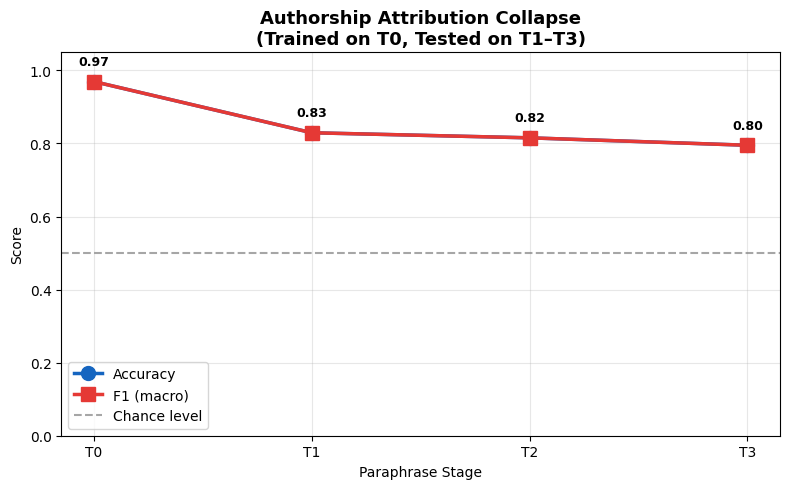

Saved: fig2_attribution_collapse.png


In [8]:
# Plot the "Identity Collapse" curve
fig, ax = plt.subplots(figsize=(8, 5))

stages_list = attr_results['stage'].tolist()
x_pos = list(range(len(stages_list)))

ax.plot(x_pos, attr_results['accuracy'].tolist(),
        marker='o', linewidth=2.5, markersize=10, color='#1565C0', label='Accuracy')
ax.plot(x_pos, attr_results['f1_macro'].tolist(),
        marker='s', linewidth=2.5, markersize=10, color='#E53935', label='F1 (macro)')

# Chance line (binary = 0.5)
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.7, label='Chance level')

ax.set_xticks(x_pos)
ax.set_xticklabels(stages_list)
ax.set_title('Authorship Attribution Collapse\n(Trained on T0, Tested on T1–T3)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Paraphrase Stage')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Annotate values
for i, row in attr_results.iterrows():
    ax.annotate(f"{row['accuracy']:.2f}",
                (x_pos[i], row['accuracy']),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / 'fig2_attribution_collapse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_attribution_collapse.png')

### Per-Paraphraser Attribution Collapse
Does the "Point of No Return" differ by paraphraser family?

  T0: Acc=0.9797  F1(macro)=0.9797
  T1: Acc=0.7432  F1(macro)=0.7421
  T2: Acc=0.8311  F1(macro)=0.8298
  T3: Acc=0.6959  F1(macro)=0.6919
  T0: Acc=0.9747  F1(macro)=0.9747


  T1: Acc=0.7574  F1(macro)=0.7545


  T2: Acc=0.7257  F1(macro)=0.7227
  T3: Acc=0.7342  F1(macro)=0.7326
  T0: Acc=0.9592  F1(macro)=0.9590
  T1: Acc=0.8776  F1(macro)=0.8739
  T2: Acc=0.8571  F1(macro)=0.8532
  T3: Acc=0.8406  F1(macro)=0.8356
  T0: Acc=0.9612  F1(macro)=0.9612
  T1: Acc=0.9579  F1(macro)=0.9579


  T2: Acc=0.9256  F1(macro)=0.9256
  T3: Acc=0.9159  F1(macro)=0.9158


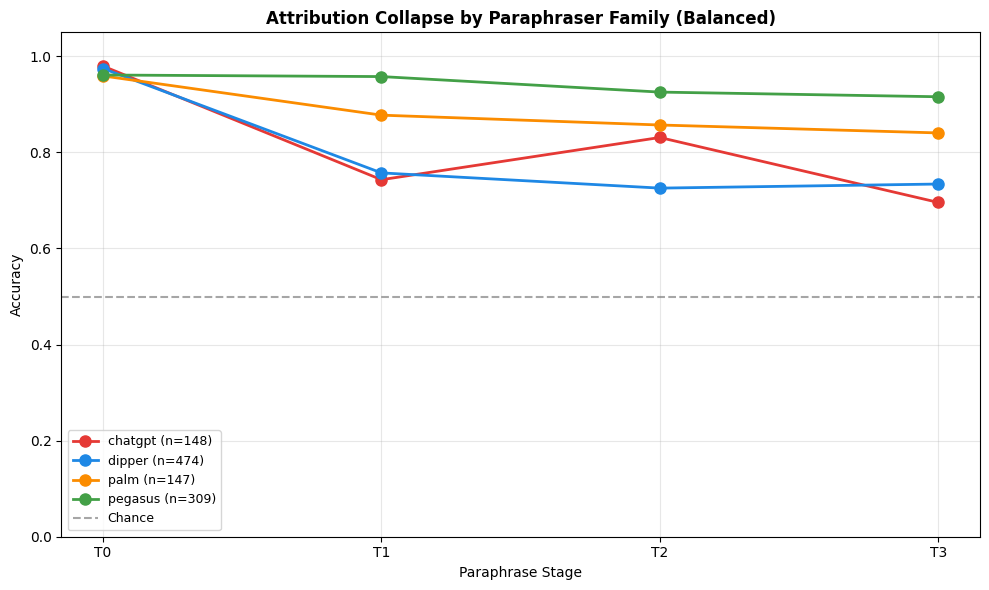

Saved: fig3_attribution_by_family.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
family_colors = {'chatgpt': '#E53935', 'dipper': '#1E88E5',
                 'pegasus': '#43A047', 'palm': '#FB8C00'}

for family_name, family_df in balanced_chains.groupby('family'):
    if family_name == 'none':
        continue
    if len(family_df) < 10:
        continue
    results = evaluate_by_stage(model_attr, vectorizer, family_df)
    ax.plot(results['stage'], results['accuracy'],
            marker='o', linewidth=2, markersize=8,
            color=family_colors.get(family_name, '#999'),
            label=f"{family_name} (n={len(family_df)})")

ax.axhline(0.5, color='grey', linestyle='--', alpha=0.7, label='Chance')
ax.set_title('Attribution Collapse by Paraphraser Family (Balanced)', fontweight='bold')
ax.set_xlabel('Paraphrase Stage')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'fig3_attribution_by_family.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_attribution_by_family.png')

---
## Section 3: Paraphraser Fingerprint Classifier

**RQ3**: Can we identify which paraphraser (ChatGPT, Dipper, Pegasus, PaLM) was used
just by looking at the text?

Use stylometric features + TF-IDF to train a 4-class RandomForest classifier on T1 data.

In [10]:
from sklearn.model_selection import train_test_split
from src.features.stylometry import extract_features_batch
from src.models.fingerprint import train_fingerprint, evaluate_fingerprint, get_feature_importance

# Use T1 texts with family labels (exclude 'none' which is T0/original)
fp_df = combined_chains[combined_chains['family'] != 'none'].copy()
print(f"Fingerprint dataset: {len(fp_df)} rows")
print(f"Family distribution:\n{fp_df['family'].value_counts()}")

# Extract stylometric features from T1 texts
print("\nExtracting stylometric features from T1 texts...")
fp_stylo = extract_features_batch(fp_df['T1'].fillna('').tolist())

# Also add TF-IDF features (top 500)
tfidf_fp = TfidfVectorizer(max_features=500, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf_fp = tfidf_fp.fit_transform(fp_df['T1'].fillna('').tolist())

# Combine stylometric + TF-IDF
import scipy.sparse
X_stylo = fp_stylo.values
X_combined = scipy.sparse.hstack([
    scipy.sparse.csr_matrix(X_stylo),
    X_tfidf_fp
])

feature_names = list(fp_stylo.columns) + list(tfidf_fp.get_feature_names_out())
y_fp = fp_df['family'].values

print(f"\nCombined feature matrix: {X_combined.shape}")
print(f"Feature names (first 10): {feature_names[:10]}")

Fingerprint dataset: 3500 rows
Family distribution:
family
dipper     1540
pegasus     992
palm        497
chatgpt     471
Name: count, dtype: int64

Extracting stylometric features from T1 texts...


  Processed 100/3500 texts


  Processed 200/3500 texts


  Processed 300/3500 texts


  Processed 400/3500 texts


...

  Processed 3200/3500 texts


  Processed 3300/3500 texts


  Processed 3400/3500 texts


  Processed 3500/3500 texts
  Done: 3500/3500 texts



Combined feature matrix: (3500, 522)
Feature names (first 10): ['sent_len_mean', 'sent_len_var', 'ttr', 'punct_ratio', 'dep_depth_mean', 'dep_depth_max', 'pos_NOUN', 'pos_VERB', 'pos_ADJ', 'pos_ADV']


In [11]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_fp, test_size=0.25, random_state=SEED, stratify=y_fp
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# Train classifier
fp_model = train_fingerprint(X_train, y_train)

# Evaluate
fp_results = evaluate_fingerprint(fp_model, X_test, y_test)

Train: 2625, Test: 875


Fingerprint training accuracy: 1.0000
Test Accuracy: 0.5829
Test F1 (macro): 0.4103

              precision    recall  f1-score   support

     chatgpt       0.70      0.24      0.35       118
      dipper       0.56      0.90      0.69       385
        palm       0.33      0.01      0.02       124
     pegasus       0.62      0.54      0.58       248

    accuracy                           0.58       875
   macro avg       0.55      0.42      0.41       875
weighted avg       0.57      0.58      0.52       875



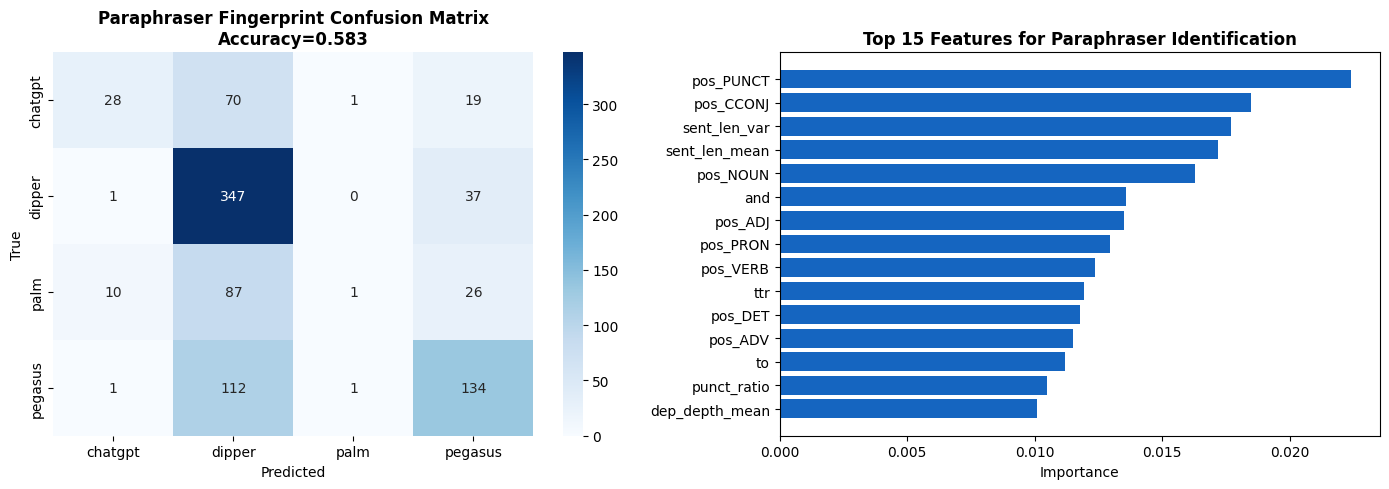

Saved: fig4_fingerprint_results.png


In [12]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion matrix
ax = axes[0]
cm = fp_results['confusion_matrix']
labels = fp_results['labels']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=labels, yticklabels=labels)
ax.set_title(f"Paraphraser Fingerprint Confusion Matrix\nAccuracy={fp_results['accuracy']:.3f}",
             fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

# Right: Feature importance
ax = axes[1]
importance_df = get_feature_importance(fp_model, feature_names, top_n=15)
ax.barh(importance_df['feature'], importance_df['importance'], color='#1565C0')
ax.set_title('Top 15 Features for Paraphraser Identification', fontweight='bold')
ax.set_xlabel('Importance')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES / 'fig4_fingerprint_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_fingerprint_results.png')

importance_df.to_csv(EXP_DATA / 'fingerprint_feature_importance.csv', index=False)

---
## Section 4: Summary of Findings

Key findings for Project Update 2 presentation:

In [13]:
print("=" * 70)
print("PHASE 2 SUMMARY — Identity Forensics")
print("=" * 70)

print("\n1. IDENTITY TRAJECTORY (t-SNE)")
print(f"   Silhouette score (t-SNE): {sil_tsne:.4f}")
print(f"   Silhouette score (PCA):   {sil_pca:.4f}")

print("\n2. AUTHORSHIP ATTRIBUTION ('Point of No Return')")
for _, row in attr_results.iterrows():
    print(f"   {row['stage']}: Accuracy={row['accuracy']:.4f}  F1={row['f1_macro']:.4f}")

# Find the Point of No Return
for _, row in attr_results.iterrows():
    if row['accuracy'] <= 0.55 and row['stage'] != 'T0':  # near chance
        print(f"   >>> Point of No Return: ~{row['stage']}")
        break
else:
    print("   >>> Identity persists through T3 (accuracy stays above chance)")

print("\n3. PARAPHRASER FINGERPRINTS")
print(f"   Classifier accuracy: {fp_results['accuracy']:.4f}")
print(f"   F1 (macro): {fp_results['f1_macro']:.4f}")
print(f"   Top features: {', '.join(importance_df['feature'].head(5).tolist())}")

print("\n" + "=" * 70)
print("All figures saved to: figures/identity_forensics/")
print("All data saved to: experiments/identity_forensics/")
print("=" * 70)

PHASE 2 SUMMARY — Identity Forensics

1. IDENTITY TRAJECTORY (t-SNE)
   Silhouette score (t-SNE): -0.0141
   Silhouette score (PCA):   -0.0036

2. AUTHORSHIP ATTRIBUTION ('Point of No Return')
   T0: Accuracy=0.9694  F1=0.9694
   T1: Accuracy=0.8293  F1=0.8293
   T2: Accuracy=0.8154  F1=0.8154
   T3: Accuracy=0.7951  F1=0.7951
   >>> Identity persists through T3 (accuracy stays above chance)

3. PARAPHRASER FINGERPRINTS
   Classifier accuracy: 0.5829
   F1 (macro): 0.4103
   Top features: pos_PUNCT, pos_CCONJ, sent_len_var, sent_len_mean, pos_NOUN

All figures saved to: figures/identity_forensics/
All data saved to: experiments/identity_forensics/
